Analyse de la perte d'utilisateurs dans le parcours client


In [9]:
#Importation des datas

import pandas as pd

data = {
    'etape': ['Commandes', 'Expédiées', 'Livrées', 'Complètes'],
    'nb': [13990, 10171, 5432, 3890]
}

df_funnel = pd.DataFrame(data)

# Calcul du taux de conversions
df_funnel['taux_conversion'] = (df_funnel['nb'] / df_funnel['nb'].iloc[0] * 100).round(2)


In [10]:
df_funnel

,etape,nb,taux_conversion
0,Commandes,13990,100.00
1,Expédiées,10171,72.70
2,Livrées,5432,38.83
3,Complètes,3890,27.81


In [11]:
#Calcul du taux de chute de chaque étape
df_funnel['taux_chute'] = (1 - df_funnel['nb'] / df_funnel['nb'].shift(1)) * 100
df_funnel['taux_chute'] = df_funnel['taux_chute'].round(2)
df_funnel

,etape,nb,taux_conversion,taux_chute
0,Commandes,13990,100.00,NaN
1,Expédiées,10171,72.70,27.30
2,Livrées,5432,38.83,46.59
3,Complètes,3890,27.81,28.39


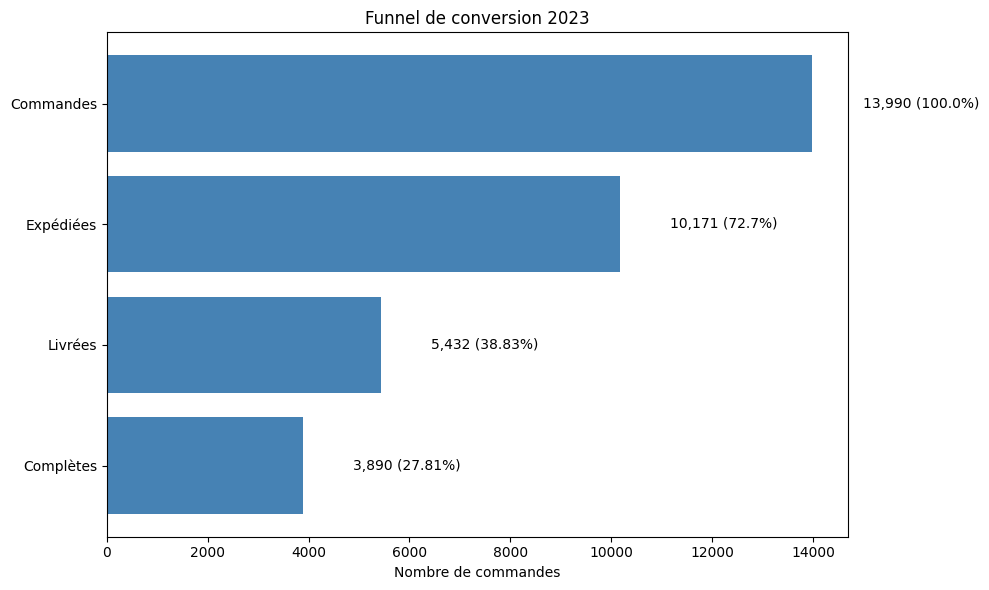

In [18]:
#Graphique en barres horizontales
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df_funnel['etape'], df_funnel['nb'], color='steelblue')


# Affichage des valeurs pour chaque étape (chiffres et taux)
for i, (bar, row) in enumerate(zip(bars, df_funnel.itertuples())):
    ax.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"{row.nb:,} ({row.taux_conversion}%)",
        va='center'
    )

ax.set_title('Funnel de conversion 2023')
ax.set_xlabel('Nombre de commandes')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('funnel_2023.png', dpi=150, bbox_inches='tight')
plt.show()
